        Course: Introduction to Machine Learning and Pattern Classification
                                    HW1
                                Anis Meysami
                            Student Number:523636

In [41]:
#Importing Packages
import numpy as np

#Probelem 1, part a: Finding normal of 
x=np.array([3.4, 1.5, 0.0, -2.2])
x=x.T

""" function for finding 1-norm """
def norm_1(var):
    norm_one=0
    for i in range(len(var)):
        norm_one += np.abs(var[i])
    return np.round(norm_one,3)

""" function for finding 2-norm or 3-norm """
def norm(var, power_val):
    norm_val=0
    for j in range(len(var)):
        norm_val += np.abs(np.power(var[j],power_val))
    inverse_pow= 1/power_val
    return np.round(np.power(norm_val, inverse_pow),3) 

""" function for finding infinity-norm """
def infinity_norm(var):
    inf_norm =np.max(np.abs(var))
    return inf_norm
#norms
norm_1_x= norm_1(x)
norm_2_x= norm(x,2)
norm_3_x= norm(x,3)
norm_inf= infinity_norm(x)


#sort norms in an ascending order
norms_array=np.array([norm_1_x , norm_2_x, norm_3_x, norm_inf])
sorted_norms=np.sort(norms_array)

#Print outputs
print(f"norm_1 of x is {norm_1_x}")
print(f"norm_2 of x is {norm_2_x}")
print(f"norm_3 of x is {norm_3_x}")
print(f"infinity-norm is {norm_inf}")
print(f"sorted norm array is {sorted_norms}")

norm_1 of x is 7.1
norm_2 of x is 4.319
norm_3 of x is 3.764
infinity-norm is 3.4
sorted norm array is [3.4   3.764 4.319 7.1  ]


In [21]:
#Probelem 1, part b: Finding distaance between X and Y
y=np.array([-1.3, 4.2, 3.0, 2.5])
y=y.T

dis=x-y

#using function of part a
dis_norm_1= norm_1(dis)
dis_norm_2= norm(dis,2)
dis_norm_inf= infinity_norm(dis)

#sort distance norm in a descending order
norm_dis_array=np.array([dis_norm_1 , dis_norm_2, dis_norm_inf])
sorted_dis_norms=np.sort(norm_dis_array)[::-1]

print(f'norm-1 distance between x and y is {dis_norm_1}')
print(f'norm-2 distance between x and y is {dis_norm_2}')
print(f'infinity-norm distance between x and y is {dis_norm_inf}')
print(f"sorted norm of distance array is {sorted_dis_norms}")

norm-1 distance between x and y is 15.1
norm-2 distance between x and y is 7.776
infinity-norm distance between x and y is 4.7
sorted norm of distance array is [15.1    7.776  4.7  ]


In [42]:
#Importing Packages
import numpy as np

#Problem 3: Eigenanalysis of Matrix B
B=np.array([[2,2,4],[1,4,7],[2,5,4]])
eigvalues, eigvectors= np.linalg.eig(B)

#Eigendecomposiotion of B Matrix
lambda_mat= np.diag(eigvalues)
Q=eigvectors
inv_Q=np.linalg.inv(Q)

reconstructed_B= Q @ lambda_mat @ inv_Q
print(f'B resulted from eigendecomposition is {reconstructed_B} so B=Q @ lambda @ Q^-1 ')

B resulted from eigendecomposition is [[2. 2. 4.]
 [1. 4. 7.]
 [2. 5. 4.]] so B=Q @ lambda @ Q^-1 


The estimated x for learning rate 0.1 is 0.0009407828688312088
The estimated y for learning rate 0.1 is 0.0005814357889713212
The estimated f(x,y) for learning rate 0.1 is 4.671979005005314e-07
_____________________________________


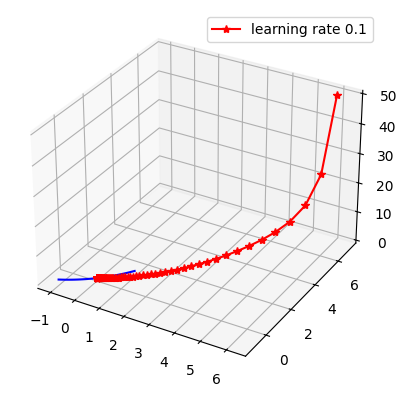

The estimated x for learning rate 0.01 is 0.0009954212567280895
The estimated y for learning rate 0.01 is 0.0006152041697820944
The estimated f(x,y) for learning rate 0.01 is 5.230412037229744e-07
_____________________________________


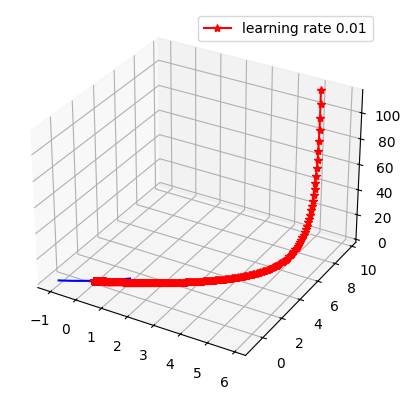

The estimated x for learning rate 0.001 is 0.000999667857147477
The estimated y for learning rate 0.001 is 0.0006178287131779151
The estimated f(x,y) for learning rate 0.001 is 5.275134506944862e-07
_____________________________________


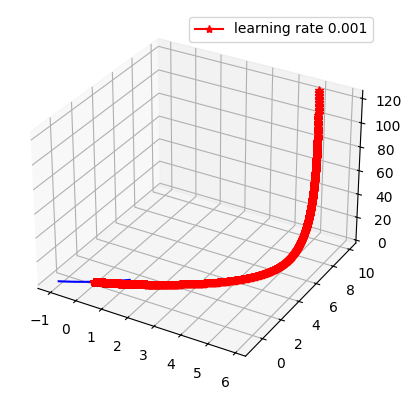

In [33]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
init=np.array([[5],[10]])
lr=[0.1, 0.01, 0.001]
real_min=np.zeros((2,1))

#function for calculation derivative of f(x,y) and return a vector
def grad_func(vec):
    grad_x=2*vec[0,0] -2*vec[1,0]
    grad_y=4*vec[1,0] -2*vec[0,0]
    grad_arr=np.array([[grad_x],[grad_y]])
    return grad_arr
  
#function for updating x and y
def update(current_xy, grad_result, lr):
    updated_xy= current_xy - lr* grad_result
    return updated_xy
    
max_itr=2000
thresh = 0.001
vec=init
def gradient_descent(vec, lr, max_itr):
    updated_x=list()
    updated_y=list()
    
    for i in range(max_itr):
        dis_x, dis_y=0,0
        it=0
        grad=grad_func(vec)
        updated_vec=update(vec, grad, lr)
        updated_x.append(updated_vec[0,0])
        updated_y.append(updated_vec[1,0])
        func=(updated_vec[0,0])**2 + 2*(updated_vec[1,0]**2) -2*updated_vec[0,0]*updated_vec[1,0]
        dis_x= np.abs(updated_vec[0,0]-real_min[0,0])
        dis_y= np.abs(updated_vec[1,0]-real_min[1,0])
        vec=updated_vec
        if dis_x <= thresh and dis_y <= thresh:
            print(f'The estimated x for learning rate {lr} is {updated_vec[0,0]}')
            print(f'The estimated y for learning rate {lr} is {updated_vec[1,0]}')
            print(f'The estimated f(x,y) for learning rate {lr} is {func}')
            print('_____________________________________')
            #Plot
            fig1=plt.figure()
            ax1=plt.axes(projection='3d')
            xd=np.linspace(-1,1)
            yd=np.linspace(-1,1)
            zd= xd**2 + 2*(yd**2) -2*xd*yd
            
            x=np.array(updated_x)
            y=np.array(updated_y)
            z=x**2 + 2*(y**2) -2*x*y
            ax1.plot3D(xd,yd,zd, color='b')
            ax1.plot3D(x,y,z, color='r', marker='*', label= f'learning rate {lr}')
            ax1.legend()
            plt.show()

            break
    return updated_x, updated_y
        
w_x_1, w_y_1= gradient_descent(init, lr[0], max_itr)     
w_x_2, w_y_2= gradient_descent(init, lr[1], max_itr)   
w_x_3, w_y_3= gradient_descent(init, lr[2], 20000)  

